# Occurrence tables, and the chapter's figures

This notebook produces the chapter's deliverable, specified in §7 of the chapter README: a
summary table of impressions, scans and distinct works per class, the occurrence evidence the
pipeline exists to produce, deferred from Chapter 2 on measured grounds. It also renders the
figures on which the chapter's quantitative argument rests.

Both are derived from frozen artifacts only. This is a **post-detection consolidation step**:
run it after Chapter 4's reviewed crops have been folded into the final catalogue. It re-derives the provenance of every
catalogue crop, renders the three figures that carry the chapter's argument, and computes class
and class-to-work tables,
occurrence table at the level of bibliographic *works*, using the corpus-wide rule in
`book_identifiers.py`. Nothing upstream is re-run and no catalogue file is written.

---

**Reads** the catalogue symlinks, the frozen review labels, the frozen hold-out results ·
**Writes** `occurrence_v1/` · **Chapter README** §4–§7

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '3_retrieval', 'Run this notebook from its own folder, 3_retrieval/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))
import book_identifiers

CATALOGUE_DIR = PROJECT_DIR / 'Fleurons' / 'Fleurons_v2_plus_retrieval'
RETRIEVAL_DIR = PROJECT_DIR / '3_retrieval_outputs'

RUN_TAG = ''
ALLOW_OVERWRITE = False


def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path


OUTPUT_DIR = guarded_mkdir(RETRIEVAL_DIR / f'occurrence_v1{RUN_TAG}')
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 140, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
INK, FOIL, RULE, FLAG = '#1f4e79', '#b0b7bd', '#444444', '#b23a3a'


def wilson(k, n, z=1.96):
    """95% Wilson (1927) interval for a binomial proportion."""
    if n == 0:
        return (0.0, 1.0)
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (max(0.0, centre - half), min(1.0, centre + half))


print(f'writing to: {OUTPUT_DIR.relative_to(PROJECT_DIR)}')

writing to: 3_retrieval_outputs/occurrence_v1


## 2. Provenance of every catalogue crop

Occurrence counts are only as sound as the accounting beneath them, so the first step assigns
every crop in the catalogue to one of three origins: **pre-retrieval** (placed by clustering
and hand curation, Chapter 2), **retrieval** (proposed by this chapter's runs and confirmed by
review, identified through the `confirmed` columns of the frozen review tables, never by
counting surviving symlinks, for the reason given in §6 of the README), and **detection**
(recovered by Chapter 4's detector, recognisable by `_detection` in the crop filename). The
scan each crop came from is recovered from its filename, and volume and work identity follow
`book_identifiers.py`.

In [2]:
records = []
for cls_dir in sorted(p for p in CATALOGUE_DIR.iterdir() if p.is_dir()):
    for link in sorted(cls_dir.iterdir()):
        target = Path(os.path.realpath(link))
        records.append({'class_name': cls_dir.name.split(' (')[0],
                        'class_dir': cls_dir.name,
                        'link_name': link.name,
                        'crop_name': target.name,
                        'in_crop_store': 'all_regions_outputs/crops' in str(target),
                        'parent': target.parent.name})
crops = pd.DataFrame(records)
assert crops['class_dir'].nunique() == 92 and len(crops) == 8547

# The scan is the crop-store folder name; for the few crops routed through the older
# curation folder as file copies, it is recovered from the link name instead.
from_link = (crops['link_name'].str.split('__').str[-1]
             .str.replace(r'_(candidate|detection).*$', '', regex=True))
crops['scan'] = np.where(crops['in_crop_store'], crops['parent'], from_link)

shortlist = pd.read_csv(RETRIEVAL_DIR / 'centroid_match_v1' / 'review_shortlist.csv')
gap_review = pd.read_csv(RETRIEVAL_DIR / 'holdout_v1' / 'gap_class_review.csv')
confirmed = set(shortlist.loc[shortlist.confirmed, 'crop_name']) | \
            set(gap_review.loc[gap_review.confirmed, 'crop_name'])
assert len(confirmed) == 664 + 32

crops['origin'] = np.where(crops['crop_name'].isin(confirmed), 'retrieval',
                  np.where(crops['crop_name'].str.contains('_detection'),
                           'detection', 'pre-retrieval'))
assert not ((crops.origin == 'retrieval') &
            crops.crop_name.str.contains('_detection')).any()

identifiers, _ = book_identifiers.identifier_table(sorted(crops['scan'].unique()))
identifiers = identifiers.rename(columns={'filename': 'scan'})
crops = crops.merge(identifiers[['scan', 'volume_id', 'work_id', 'dated']],
                    on='scan', how='left')
crops.to_csv(OUTPUT_DIR / 'catalogue_provenance.csv', index=False)

print(crops['origin'].value_counts().to_string())
print(f"\nscans: {crops['scan'].nunique()}   volumes: {crops['volume_id'].nunique()}   "
      f"works: {crops['work_id'].nunique()}")
print('\ndetection crops by class:')
print(crops.loc[crops.origin == 'detection', 'class_dir'].value_counts().to_string())
absent = sorted(confirmed - set(crops['crop_name']))
print(f'\nconfirmed recoveries not in the catalogue: {len(absent)}: {absent}')

origin
pre-retrieval    7152
detection         702
retrieval         693

scans: 514   volumes: 55   works: 49

detection crops by class:
class_dir
Fleuron_72 (1172)    494
Fleuron_73 (487)     121
Fleuron_2 (319)       54
Fleuron_74 (131)      33

confirmed recoveries not in the catalogue: 3: ['camoeuli[liba]59.nu.1_candidate_0000.png', 'camoeuli[liba]59.nu.1_candidate_0030.png', 'camoeuli[liba]59.nu.1_candidate_0031.png']


**Takeaway.** Three accounting facts govern every count that follows.

**Detector-derived crops sit in four classes, not one.** `Fleuron_72` (494), `Fleuron_73` (121)
and `Fleuron_74` (33) hold them in larger numbers than `Fleuron_2` itself (54). Work counts
therefore exclude *all* detection crops, for every class, rather than special-casing one, since
Chapter 4 ran its detector on selected designs only and those counts are not comparable across
classes.

**693 of the 696 confirmed recoveries are in the catalogue.** The three absentees are all
proposals for `Fleuron_64`, whose folder now holds three *different* crops of the same design
from the same scan: later curation replaced the confirmed links with better impressions. The
class's occurrence counts are unaffected, same scan, same work, but 696 should be read as
recoveries confirmed at review time, not as a count of surviving catalogue members.

**Retrieval and detection labels do not overlap at crop-file level.** No confirmed retrieval crop
has a detection-derived filename, so the three recorded origins partition catalogue files exactly.
This does not test spatial overlap between separately generated boxes on the same scan.

## 3. The method and the pool, in one figure

The chapter's central quantitative contrast is between §4 and §5: the same method confirms
0.297 of selected proposals on the residual pool and assigns 0.997 of held-out members correctly
in a closed-world self-consistency check. The two panels condition differently, reviewer judgement
on a residual shortlist against catalogue membership on a constructed one, and neither number is
an external estimate of corpus-wide retrieval accuracy.

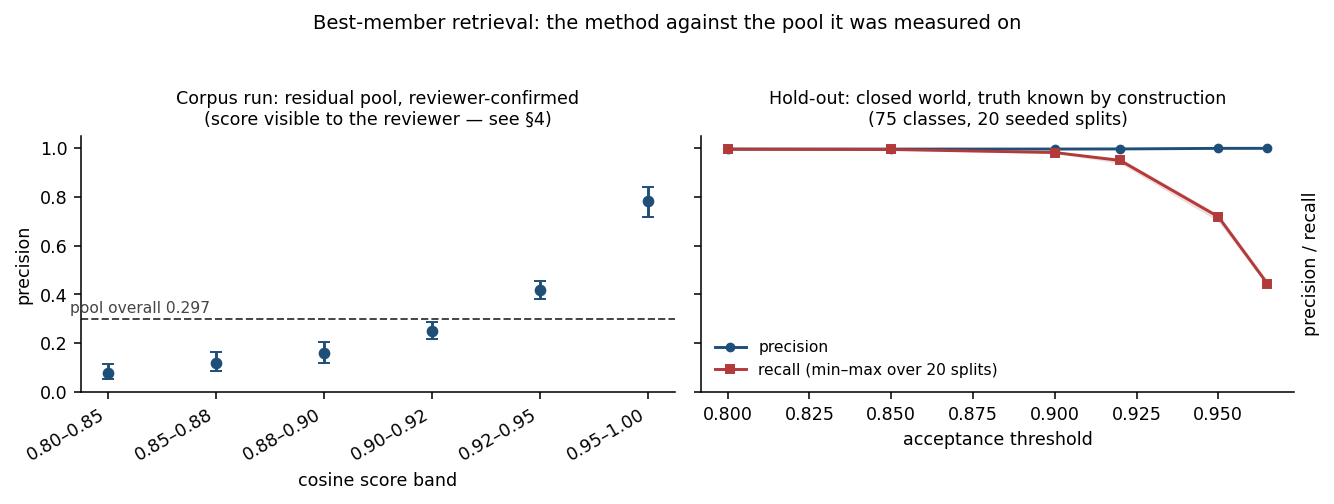

In [3]:
bands = [(0.80, 0.85), (0.85, 0.88), (0.88, 0.90), (0.90, 0.92), (0.92, 0.95), (0.95, 1.001)]
band_rows = []
for lo, hi in bands:
    sub = shortlist[(shortlist.score >= lo) & (shortlist.score < hi)]
    low, high = wilson(sub.confirmed.sum(), len(sub))
    band_rows.append({'band': f'{lo:.2f}–{min(hi, 1.0):.2f}', 'n': len(sub),
                      'precision': sub.confirmed.mean(), 'low': low, 'high': high})
band_table = pd.DataFrame(band_rows)

holdout = pd.read_csv(RETRIEVAL_DIR / 'holdout_v1' / 'holdout_summary.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)

x = np.arange(len(band_table))
ax1.errorbar(x, band_table.precision,
             yerr=[band_table.precision - band_table.low,
                   band_table.high - band_table.precision],
             fmt='o', color=INK, ecolor=INK, capsize=3, markersize=5)
ax1.axhline(0.297, color=RULE, linestyle='--', linewidth=1)
ax1.text(-0.35, 0.31, 'pool overall 0.297', fontsize=8, color=RULE, va='bottom')
ax1.set_xticks(x, band_table.band, rotation=30, ha='right')
ax1.set_xlabel('cosine score band')
ax1.set_ylabel('precision')
ax1.set_ylim(0, 1.05)
ax1.set_title('Corpus run: residual pool, reviewer-confirmed\n(score visible to the reviewer — see §4)',
              fontsize=9)

ax2.plot(holdout.threshold, holdout.precision, 'o-', color=INK, markersize=4,
         label='precision')
ax2.fill_between(holdout.threshold, holdout.recall_low, holdout.recall_high,
                 color=FLAG, alpha=0.18, linewidth=0)
ax2.plot(holdout.threshold, holdout.recall, 's-', color=FLAG, markersize=4,
         label='recall (min–max over 20 splits)')
ax2.set_xlabel('acceptance threshold')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('precision / recall')
ax2.set_title('Hold-out: closed world, truth known by construction\n(75 classes, 20 seeded splits)',
              fontsize=9)
ax2.legend(frameon=False, fontsize=8, loc='lower left')

fig.suptitle('Best-member retrieval: the method against the pool it was measured on', y=1.04,
             fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'method_vs_pool.png', bbox_inches='tight')
plt.show()

**Takeaway.** The left panel's gradient cannot be read as validation of the score, because the reviewer saw
the score (README §4); the right panel supplies that validation with no reviewer in the loop.
Together they show that ordinary catalogue members are easy to reassign while the selected
residual-pool shortlist is difficult to confirm; the design does not isolate the cause of that
difference. In the closed-world check, the threshold spends recall, not precision, from 0.997 retained at
0.80 down to 0.719 at 0.95, which is why review-efficiency, not thresholded precision, is the
operationally meaningful property. The Wilson bars treat proposals as independent and are
descriptive; they are not scan- or class-clustered uncertainty intervals.

## 4. Where the errors are

152 misassignments occur across the 20 hold-out repeats, involving 34 of the 2,775 possible
class pairs; the ten most confused pairs account for 69% of all errors.

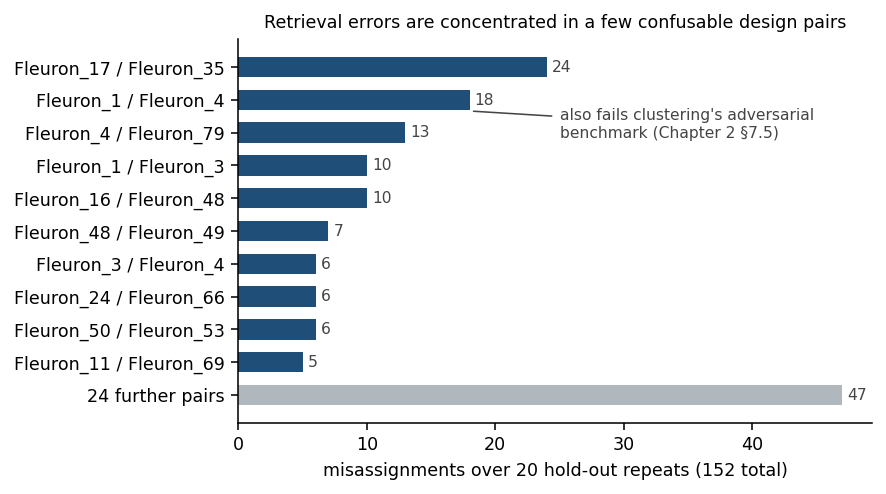

In [4]:
confusions = (pd.read_csv(RETRIEVAL_DIR / 'holdout_v1' / 'holdout_confusions.csv')
              .sort_values('errors', ascending=False).reset_index(drop=True))
top = confusions.head(10).copy()
rest = confusions.iloc[10:]

labels = [f'{a} / {b}' for a, b in zip(top['class A'], top['class B'])]
labels.append(f'{len(rest)} further pairs')
values = list(top.errors) + [rest.errors.sum()]
colors = [INK] * len(top) + [FOIL]

fig, ax = plt.subplots(figsize=(6.4, 3.6))
y = np.arange(len(values))[::-1]
ax.barh(y, values, color=colors, height=0.62)
for yi, v in zip(y, values):
    ax.text(v + 0.4, yi, str(v), va='center', fontsize=8, color=RULE)
ax.set_yticks(y, labels)
ax.set_xlabel('misassignments over 20 hold-out repeats (152 total)')
ax.set_title('Retrieval errors are concentrated in a few confusable design pairs', fontsize=9)
i_cross = labels.index('Fleuron_1 / Fleuron_4')
ax.annotate('also fails clustering\'s adversarial\nbenchmark (Chapter 2 §7.5)',
            xy=(top.errors.iloc[i_cross], y[i_cross] - 0.34),
            xytext=(top.errors.iloc[i_cross] + 7, y[i_cross] - 1.15),
            fontsize=8, color=RULE,
            arrowprops=dict(arrowstyle='-', color=RULE, linewidth=0.8))
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'retrieval_error_concentration.png', bbox_inches='tight')
plt.show()

**Takeaway.** Within the 75 eligible classes and this crop-level protocol, observed errors are
concentrated rather than diffuse, and the same kind of failure recurs across chapters: the
clustering chapter's confusable-designs figure shows crop pairs whose embeddings exceed the
identity threshold and which a reviewer judged to be different designs, differing only in a lobe
count or an interior element. Two methods, two procedures, two samples, one limitation, which
locates it in the shared DINOv2 representation. Every class involved in one of these 34 pairs is
flagged in the occurrence table below, because a count resting on a confusable pair needs the
two classes checked against each other by eye before it is published. Classes not flagged by this
test are not thereby certified confusion-free.

## 5. Occurrence across works

The tables this section writes are the chapter's deliverable: for each of 92 fleuron classes,
how many verified impressions exist, over how many scans, volumes and bibliographic works, plus
the work IDs behind each count. Numeric and letter-based names are class identifiers only; all
92 classes represent the same unit of analysis: a single ornamental design (fleuron).
Counting rules, fixed before the numbers were read:

- **Works, not volumes**, per `book_identifiers.py`; volume counts are retained as a column.
- **Detection crops are excluded from every work count** (`works` below), because Chapter 4
  ran its detector on selected designs only and those counts are not comparable across
  classes. A separate `works_incl_detection` column records the difference.
- `works_pre_retrieval` counts works reachable from pre-retrieval crops alone, so the
  difference to `works` is exactly what this chapter's retrieval added.
- `confusable_with` lists partners from the 34 hold-out confusion pairs and the six
  adversarial pairs of Chapter 2 §7.5. A cross-work claim for a flagged class requires the
  pair to be checked by eye first.
- The long-form class-to-work table retains detection-only work rows and marks whether each row
  contributes to the primary, detection-excluded reach count. Work IDs remain filename-derived
  until checked against bibliographic records.

In [5]:
CH2_ADVERSARIAL_PAIRS = [('Fleuron_12', 'Fleuron_22'), ('Fleuron_38', 'Fleuron_9'),
                         ('Fleuron_10', 'Fleuron_42'), ('Fleuron_20', 'Fleuron_25'),
                         ('Fleuron_57', 'Fleuron_7'), ('Fleuron_3', 'Fleuron_43')]
partners = {}
for a, b in list(zip(confusions['class A'], confusions['class B'])) + CH2_ADVERSARIAL_PAIRS:
    partners.setdefault(a, set()).add(b)
    partners.setdefault(b, set()).add(a)


def occurrence(sub):
    no_det = sub[sub.origin != 'detection']
    pre = sub[sub.origin == 'pre-retrieval']
    return pd.Series({
        'crops': len(sub),
        'crops_pre_retrieval': (sub.origin == 'pre-retrieval').sum(),
        'crops_retrieval': (sub.origin == 'retrieval').sum(),
        'crops_detection': (sub.origin == 'detection').sum(),
        'scans': no_det['scan'].nunique(),
        'volumes': no_det['volume_id'].nunique(),
        'works': no_det['work_id'].nunique(),
        'works_pre_retrieval': pre['work_id'].nunique(),
        'works_incl_detection': sub['work_id'].nunique(),
    })


occurrence_table = (crops.groupby('class_name').apply(occurrence, include_groups=False)
                    .astype(int).reset_index())
occurrence_table['works_added_by_retrieval'] = (occurrence_table.works -
                                                occurrence_table.works_pre_retrieval)
occurrence_table['confusable_with'] = occurrence_table.class_name.map(
    lambda c: ';'.join(sorted(partners.get(c, set()))))
occurrence_table = occurrence_table.sort_values('works', ascending=False)
occurrence_table.to_csv(OUTPUT_DIR / 'occurrence_by_class.csv', index=False)

class_work = (crops.groupby(['class_name', 'work_id'])
              .agg(crops=('crop_name', 'size'), scans=('scan', 'nunique'),
                   crops_pre_retrieval=('origin', lambda s: (s == 'pre-retrieval').sum()),
                   crops_retrieval=('origin', lambda s: (s == 'retrieval').sum()),
                   crops_detection=('origin', lambda s: (s == 'detection').sum()))
              .reset_index())
class_work['included_in_primary_reach'] = (
    class_work.crops_pre_retrieval + class_work.crops_retrieval > 0)
class_work = class_work.sort_values(['class_name', 'work_id'])
class_work.to_csv(OUTPUT_DIR / 'occurrence_by_class_work.csv', index=False)

recurrent = (occurrence_table.works >= 2).sum()
movers = ((occurrence_table.works_pre_retrieval < 2) & (occurrence_table.works >= 2)).sum()
print(occurrence_table.head(10).to_string(index=False))
print(f'\nclasses spanning >= 2 works: {recurrent} of {len(occurrence_table)}'
      f'   (median works per class: {occurrence_table.works.median():.0f})')
print(f'work-occurrences added by retrieval: {occurrence_table.works_added_by_retrieval.sum()} '
      f'across {(occurrence_table.works_added_by_retrieval > 0).sum()} classes')
print(f'classes crossing the two-work bar through retrieval alone: {movers}')
det_reach = occurrence_table[occurrence_table.works_incl_detection != occurrence_table.works]
print(f'classes whose observed work reach grows when detection is included: {len(det_reach)}')
print(det_reach[['class_name', 'works', 'works_incl_detection']].to_string(index=False))

class_name  crops  crops_pre_retrieval  crops_retrieval  crops_detection  scans  volumes  works  works_pre_retrieval  works_incl_detection  works_added_by_retrieval                                                                      confusable_with
Fleuron_16    305                  297                8                0     92       27     23                   23                    23                         0                                                                           Fleuron_48
 Fleuron_1   1968                 1929               39                0    153       25     22                   22                    22                         0 Fleuron_10;Fleuron_19;Fleuron_3;Fleuron_4;Fleuron_40;Fleuron_5;Fleuron_56;Fleuron_76
Fleuron_21    225                  210               15                0     93       25     21                   20                    21                         1                                                                                     


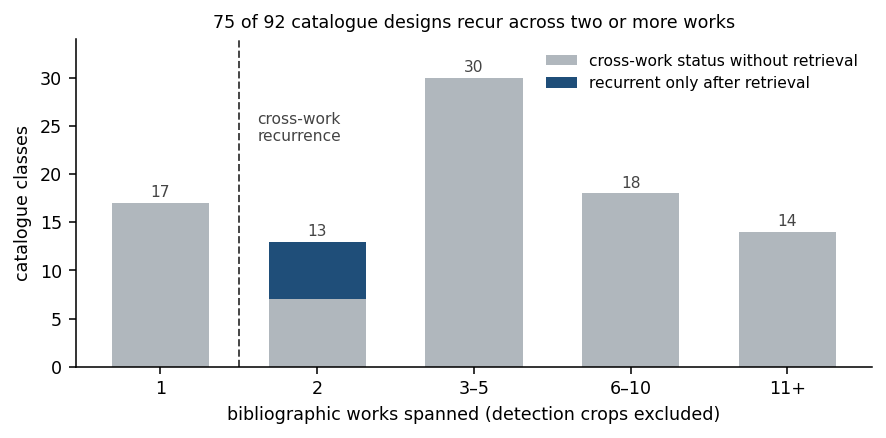

In [6]:
counts = occurrence_table.works
bins = {'1': (counts == 1), '2': (counts == 2), '3–5': (counts >= 3) & (counts <= 5),
        '6–10': (counts >= 6) & (counts <= 10), '11+': (counts >= 11)}
crossed = ((occurrence_table.works_pre_retrieval < 2) & (occurrence_table.works >= 2))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(bins))
base = [int((mask & ~crossed).sum()) for mask in bins.values()]
gained = [int((mask & crossed).sum()) for mask in bins.values()]
ax.bar(x, base, color=FOIL, width=0.62, label='cross-work status without retrieval')
ax.bar(x, gained, bottom=base, color=INK, width=0.62,
       label='recurrent only after retrieval')
ax.set_ylim(0, max(b + g for b, g in zip(base, gained)) + 4)
for xi, (b, g) in enumerate(zip(base, gained)):
    ax.text(xi, b + g + 0.6, str(b + g), ha='center', fontsize=8, color=RULE)
ax.axvline(0.5, color=RULE, linestyle='--', linewidth=1)
ax.text(0.62, ax.get_ylim()[1] * 0.78, 'cross-work\nrecurrence', fontsize=8, color=RULE,
        va='top')
ax.set_xticks(x, list(bins))
ax.set_xlabel('bibliographic works spanned (detection crops excluded)')
ax.set_ylabel('catalogue classes')
ax.set_title('75 of 92 catalogue designs recur across two or more works', fontsize=9)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'occurrence_reach.png', bbox_inches='tight')
plt.show()

**Takeaway.** **75 of 92 fleuron classes recur across two or more bibliographic works**, with a
median reach of four works. The widest-reaching design, `Fleuron_16`, spans 23 of the corpus's
51 works. Retrieval adds 43 work-occurrences across 28 classes; six classes cross the two-work
recurrence bar only through retrieval. The long-form
`occurrence_by_class_work.csv` exposes the filename-derived work IDs behind those counts. Including
detection does not change the 75-of-92 recurrence threshold, but widens observed reach for
`Fleuron_72` (9→13 works), `Fleuron_73` (14→16), and `Fleuron_74` (12→13).

Four qualifications bound the table, all inherited and stated rather than new. The counts are
**lower bounds**: segmentation recall was 0.746, retrieval is not exhaustive, and Chapter 4 shows
impressions exist that were never extracted. Counts for classes flagged `confusable_with` are
conditional on an eye-check of the pair. The three look-alike identifier families are counted as
separate works pending bibliographic confirmation, which may overstate reach if a family proves to
be one work. And no
chronological reading is attached, because five volumes carry no year and two-digit years have
not been confirmed against catalogue records; the per-fleuron case studies that would use dates
remain outstanding (§9 of the README).

## 6. What this notebook establishes

1. Every catalogue crop is assigned a provenance, 7,152 pre-retrieval, 693 retrieval, 702
   detection, written to
   `occurrence_v1/catalogue_provenance.csv`, with two corrections to the README recorded:
   detector crops occupy four classes, and 693 of the 696 confirmed recoveries survive in the
   catalogue.
2. The chapter's argument now has figures: method-against-pool (§3), error concentration (§4),
   and occurrence reach (§5), in `occurrence_v1/figures/`.
3. **The deliverable exists**: `occurrence_v1/occurrence_by_class.csv` gives impressions,
   scans, volumes and works per design under fixed counting rules;
   `occurrence_v1/occurrence_by_class_work.csv` supplies the underlying work IDs.
4. Scope is explicit: all 92 classes are single ornamental designs (fleurons), and 75 are
   evidenced as recurrent.
5. Retrieval adds 43 work-occurrences across 28 classes; six become recurrent only because of it.